---
## Step 0: Installation and Imports

Required libraries:
- **PyMuPDF (fitz)**: PDF extraction with native Arabic Unicode support
- **pdfplumber**: Alternative extraction oriented towards tables/columns
- **arabic-reshaper + python-bidi**: Correct RTL text rendering in matplotlib
- **scikit-learn**: TF-IDF vectorization and KMeans clustering
- **pandas / numpy / matplotlib / seaborn**: Data science and visualization

In [1]:
!pip install pdfplumber PyMuPDF arabic-reshaper python-bidi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 440.6 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 82.1 MB/s eta 0:00:00


In [ ]:
import fitz                         # PyMuPDF
import pdfplumber
import re
import os
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os

# Auto-detect PDF path in Kaggle input folders
PDF_ARABIC = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.pdf') and 'MA52' in f:
            PDF_ARABIC = os.path.join(root, f)
            print('PDF found at:', PDF_ARABIC)
            break

# Fallback with the correct Kaggle dataset slug
if PDF_ARABIC is None:
    PDF_ARABIC = 'code de la route MA52_05.pdf'
    print('Using fallback path:', PDF_ARABIC)



from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

try:
    import arabic_reshaper
    from bidi.algorithm import get_display
    ARABIC_DISPLAY = True
except ImportError:
    ARABIC_DISPLAY = False
    print('Warning: arabic_reshaper not available')

plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

OUTPUT_CSV = 'export_final.csv'

print('All libraries loaded successfully')
print('  PyMuPDF version :', fitz.version[0])
print('  pandas  version :', pd.__version__)
print('  Arabic display  :', ARABIC_DISPLAY)

PDF found at: /kaggle/input/datasets/sohaibelkhatab/code-de-la-route-ma52-05/code de la route MA52_05.pdf
All libraries loaded successfully
  PyMuPDF version : 1.27.2.2
  pandas  version : 2.3.3
  Arabic display  : True


---
## Step 1: Loading and Extracting from PDF Files

### 1.1 Arabic PDF (main source)

The file **`code de la route MA52_05.pdf`** is the official text of Law 52.05 published by the **General Secretariat of the Moroccan Government**. It contains **126 pages** with fully extractable numeric Arabic Unicode text.

In [3]:
import os, fitz

# Resolve the PDF path automatically on Kaggle
PDF_ARABIC = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.pdf') and 'MA52' in f:
            PDF_ARABIC = os.path.join(root, f)
            print('PDF found at:', PDF_ARABIC)
            break
    if PDF_ARABIC:
        break

if PDF_ARABIC is None:
    raise FileNotFoundError("PDF not found! Check that your dataset is attached.")

def extract_arabic_pdf(pdf_path):
    pages = []
    doc = fitz.open(pdf_path)
    for page_num in range(len(doc)):
        page = doc[page_num]
        text = page.get_text('text')
        pages.append({'page': page_num + 1, 'text': text})
    doc.close()
    print(f'  Extracted {len(pages)} pages from "{pdf_path}"')
    return pages

print('Loading Arabic PDF...')
pages_arabic = extract_arabic_pdf(PDF_ARABIC)

print(f'\nSample — Page 1 (first 300 chars):')
print('-' * 60)
print(pages_arabic[0]['text'][:300])


PDF found at: /kaggle/input/datasets/sohaibelkhatab/code-de-la-route-ma52-05/code de la route MA52_05.pdf
Loading Arabic PDF...
  Extracted 126 pages from "/kaggle/input/datasets/sohaibelkhatab/code-de-la-route-ma52-05/code de la route MA52_05.pdf"

Sample — Page 1 (first 300 chars):
------------------------------------------------------------
تم إعداد هذه النسخة من أجل تسهيل 
مقروئية النص، وال يحتج إال بالنصوص 
في صيغتها املنشورة بالجريدة الرسمية
  المتعلق52.05 القانون رقم
،بمدونة السير على الطرق
كما وقع تغييره وتتميمه
صيغة موطدة بتاريخ
2024 يوليو10



In [4]:
raw_text = '\n'.join(p['text'] for p in pages_arabic)

print('Raw Arabic corpus statistics:')
print('  Total characters:', len(raw_text))
print('  Total lines     :', raw_text.count(chr(10)))
print('  Extracted pages :', len(pages_arabic))

print('\n' + '-' * 65)
print('Raw excerpt - Page 2 (start of the legislative body):')
print('-' * 65)
print(pages_arabic[1]['text'][:600])

Raw Arabic corpus statistics:
  Total characters: 223861
  Total lines     : 4051
  Extracted pages : 126

-----------------------------------------------------------------
Raw excerpt - Page 2 (start of the legislative body):
-----------------------------------------------------------------
1
األمانة العامة للحكومة
 52.05 القانون رقم
 1.10.07 املتعلق بمدونة السير على الطرق الصادر بتنفيذه الظهير الشريف رقم
،)2010  فبراير11( 1431  من صفر26 بتاريخ
كما وقع تغييره وتتميمه
)2168 : )، ص2010  مارس25(1431  ربيع اآلخر8  بتاريخ5824 ج.ر عدد(
الكتاب األول
شروط السير على الطريق العمومية
القسم األول
رخصة السياقة
الباب األول
إلزامية رخصة السياقة
1 املادة
ال يجوز ألي شخص أن يسوق مركبة ذات محرك أو مجموعة مركبات على الطريق العمومية
 ما لم يكن حاصال على رخصة للسياقة سارية الصالحية ومسلمة من قبل اإلدارة، تناسب صنف
.املركبة أو مجموعة املركبات التي يسوقها
2 املادة
: استثناء من أحكام املادة األولى أعاله


---
## Step 2: Arabic Text Preprocessing

### Arabic-specific challenges

| Problem | Description | Solution |
|---------|-------------|----------|
| **Tashkeel (تشكيل)** | Diacritics U+064B-U+065F | Removal via regex |
| **Hamza (همزة)** | أ / إ / آ / ء / ٱ | Normalization -> ا |
| **Ta Marbuta (ة)** | Interchangeable with ه at end of word | Normalization -> ه |
| **Alef Maqsoura (ى)** | Ya variant in final position | Normalization -> ي |
| **Waw Hamza (ؤ)** | Waw variant | Normalization -> و |

### Bidirectional text problem (BiDi)

Arabic is written **right to left** (RTL), but digits and parentheses follow **left to right** (LTR) direction. This creates **ambiguities** during:

- **PDF extraction**: PyMuPDF extracts lines in the Unicode logical order. In an Arabic PDF, mixed elements (parentheses + numbers) may appear reversed. For example, `(500 درهم)` (visual display) is stored as `500(` then `درهم` in the Unicode stream.
- **matplotlib rendering**: The rendering engine is LTR by default; `arabic-reshaper` + `python-bidi` fix the letter shapes and display order.
- **Regex patterns**: Patterns must be written in **Unicode logical order** (different from the visual RTL order).

**Applicable standard:** Unicode BiDi Algorithm (TR#9) implemented in `python-bidi`.

### Practical consequence: Fine amount extraction

In this PDF, a fine like `(500 درهم)` is extracted in the logical stream as:
```
) درهم 500(
```
The regex must therefore search for **a number on the same line as the word درهم**, not necessarily adjacent to it.

In [5]:
def remove_tashkeel(text):
    """Removes Arabic diacritics (Tashkeel) U+064B-U+065F."""
    return re.sub(r'[\u064B-\u065F\u0670]', '', text)


def normalize_arabic(text):
    """
    Normalizes Arabic graphical variants:
    - All forms of Alef/Hamza  -> \u0627
    - Ta Marbuta (\u0629)       -> \u0647
    - Alef Maqsoura (\u0649) and Ya Hamza -> \u064a
    - Waw Hamza (\u0624)        -> \u0648
    """
    text = re.sub(r'[\u0623\u0625\u0622\u0671]', '\u0627', text)  # Alef variants -> ا
    text = re.sub(r'\u0629', '\u0647', text)                      # Ta Marbuta -> ه
    text = re.sub(r'[\u0626\u0649]', '\u064a', text)              # Ya variants -> ي
    text = re.sub(r'\u0624', '\u0648', text)                      # Waw Hamza -> و
    return text


def clean_text(text, normalize=True):
    """
    Full cleaning pipeline for Arabic text.
    normalize=True for regex searching (normalizes variants).
    normalize=False to keep the text human-readable.
    """
    text = remove_tashkeel(text)
    if normalize:
        text = normalize_arabic(text)
    # Remove invisible Unicode direction characters
    text = re.sub(r'[\u200B-\u200F\u202A-\u202E\uFEFF]', '', text)
    # Remove isolated page numbers (e.g. \n5\n)
    text = re.sub(r'\n\d{1,3}\n', '\n', text)
    # Multiple spaces
    text = re.sub(r'[ \t]{2,}', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()


def arabic_for_display(text):
    """Prepares Arabic text for correct rendering in matplotlib."""
    if ARABIC_DISPLAY and text:
        return get_display(arabic_reshaper.reshape(str(text)))
    return str(text)


# Application
cleaned_raw  = clean_text(raw_text, normalize=False)  # for segmentation
cleaned_norm = clean_text(raw_text, normalize=True)   # for regex search

print('Preprocessing results:')
print('  Before:', len(raw_text), 'characters')
print('  After :', len(cleaned_raw), 'characters')
print('  Reduction:', round((1 - len(cleaned_raw)/len(raw_text))*100, 1), '%')

# Normalization example
ex = '\u0627\u0644\u0631\u064f\u0643\u064f\u0648\u0628\u064f \u0639\u0644\u0649 \u0627\u0644\u0633\u064e\u064a\u064e\u0651\u0627\u0631\u064e\u0629\u0650 \u064a\u064e\u0633\u0652\u062a\u064e\u0648\u062c\u0650\u0628\u064f \u0631\u064f\u062e\u0652\u0635\u064e\u0629\u064e \u0627\u0644\u0633\u064e\u0651\u0627\u0642\u064e\u0629\u0650'
print('\nNormalization example:')
print('  Before:', ex)
print('  After :', clean_text(ex))

Preprocessing results:
  Before: 223861 characters
  After : 222003 characters
  Reduction: 0.8 %

Normalization example:
  Before: الرُكُوبُ على السَيَّارَةِ يَسْتَوجِبُ رُخْصَةَ السَّاقَةِ
  After : الركوب علي السياره يستوجب رخصه الساقه


---
## Step 3: Article Segmentation

### Segmentation strategy

Law 52.05 is structured into **numbered articles** (`المادة N`). Our segmenter:

1. Detects the article start pattern
2. Splits the text at each occurrence
3. Preserves the full text of each article for individual processing

### Critical note on BiDi and PDF extraction

In the Unicode logical stream extracted by PyMuPDF from this Arabic PDF, the article number appears **before** the word `املادة` rather than after (RTL logical order). So visually we see `المادة 1` (RTL), but in the Unicode stream it is `1 املادة` (LTR). Our regex targets the pattern **`\d+ املادة`**.

In [6]:
# Validate the pattern in the raw text
test_matches = re.findall(r'(\d+)\s+(\u0627\u0645\u0644\u0627\u062f\u0629|\u0627\u0644\u0645\u0627\u062f\u0629|\u0627\u0645\u0644\u0627\u062f\u0647|\u0627\u0644\u0645\u0627\u062f\u0647)', raw_text[:3000])
print('Pattern validation on the first 3,000 characters:')
print('  Matches found:', test_matches[:5])


def segment_into_articles(text):
    """
    Segments the text into individual articles.
    
    BiDi note: In the Unicode logical stream from PyMuPDF on this PDF,
    article markers appear as:
       '\n1 املادة\n' (number BEFORE the word, logical order)
    Article word variants:
       - املادة (with Alef Wasla ٱ)
       - المادة (canonical form with ا)
       - املاده / المادة (after Ta Marbuta normalization)
    """
    pattern = re.compile(
        r'(?:^|\n)\s*(\d+)\s+(?:\u0627\u0645\u0644\u0627\u062f\u0629|\u0627\u0644\u0645\u0627\u062f\u0629|\u0627\u0645\u0644\u0627\u062f\u0647|\u0627\u0644\u0645\u0627\u062f\u0647)\s*(?:\n|$)',
        re.UNICODE | re.MULTILINE
    )
    matches = list(pattern.finditer(text))
    articles = []
    for idx, m in enumerate(matches):
        art_num = int(m.group(1))
        start   = m.start()
        end     = matches[idx+1].start() if idx+1 < len(matches) else len(text)
        articles.append({
            'article_num': art_num,
            'raw_text'   : text[start:end].strip()
        })
    return articles


# Segmentation
articles = segment_into_articles(cleaned_raw)

print('\nSegmentation complete:')
print('  Articles detected:', len(articles))
if articles:
    nums    = [a['article_num'] for a in articles]
    avg_len = int(np.mean([len(a['raw_text']) for a in articles]))
    print('  First article  :', nums[0])
    print('  Last article   :', nums[-1])
    print('  Average length :', avg_len, 'characters')
    print('\n' + '-' * 60)
    print('Preview of article 1:')
    print('-' * 60)
    print(articles[0]['raw_text'][:450])

Pattern validation on the first 3,000 characters:
  Matches found: [('1', 'املادة'), ('2', 'املادة'), ('3', 'املادة'), ('4', 'املادة'), ('5', 'املادة')]

Segmentation complete:
  Articles detected: 316
  First article  : 1
  Last article   : 318
  Average length : 699 characters

------------------------------------------------------------
Preview of article 1:
------------------------------------------------------------
1 املادة
ال يجوز ألي شخص أن يسوق مركبة ذات محرك أو مجموعة مركبات على الطريق العمومية
 ما لم يكن حاصال على رخصة للسياقة سارية الصالحية ومسلمة من قبل اإلدارة، تناسب صنف
.املركبة أو مجموعة املركبات التي يسوقها


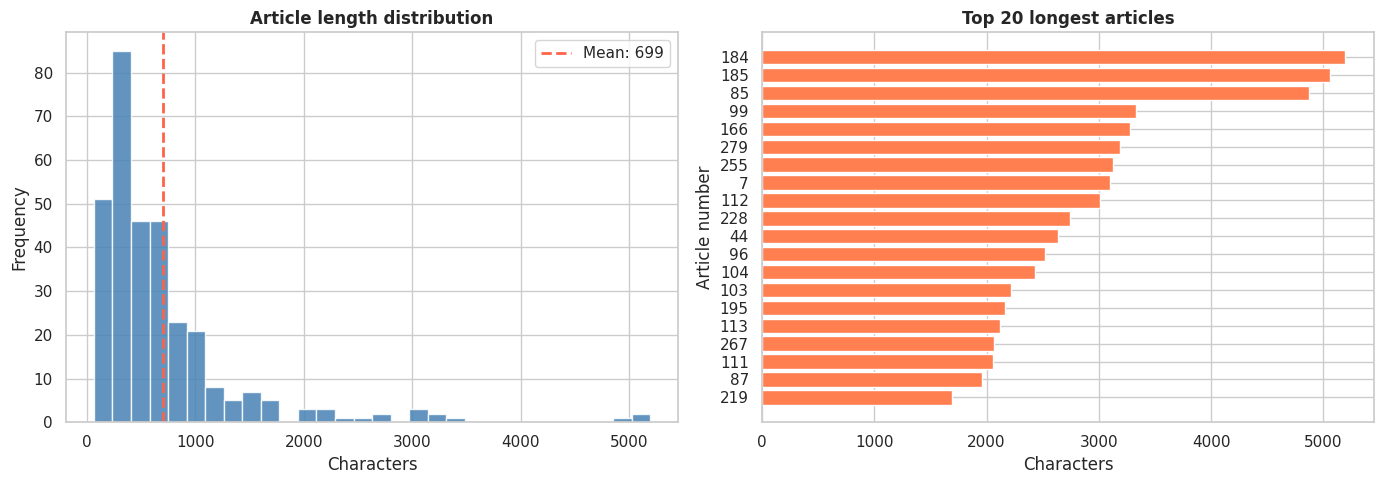

Chart saved: article_distribution.png


In [7]:
# Article length distribution
if articles:
    art_lengths = [len(a['raw_text']) for a in articles]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(art_lengths, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0].axvline(np.mean(art_lengths), color='tomato', lw=2, ls='--',
                    label='Mean: ' + str(int(np.mean(art_lengths))))
    axes[0].set_title('Article length distribution', fontweight='bold')
    axes[0].set_xlabel('Characters')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()

    top20 = sorted(articles, key=lambda x: len(x['raw_text']), reverse=True)[:20]
    axes[1].barh([str(a['article_num']) for a in top20],
                 [len(a['raw_text']) for a in top20],
                 color='coral', edgecolor='white')
    axes[1].set_title('Top 20 longest articles', fontweight='bold')
    axes[1].set_xlabel('Characters')
    axes[1].set_ylabel('Article number')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.savefig('article_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Chart saved: article_distribution.png')

---
## Step 4: Advanced Extraction via Regular Expressions

### Extraction patterns

We define **14 regex patterns** tailored to normalized Arabic legal text.

**Key technique:** For fines in dirhams, we use a **line-by-line** approach: if the word `درهم` (dirham) is present on a line, we extract all numbers from that line. This handles the RTL case where the parenthesis surrounding the amount is reversed in the Unicode logical stream.

| Field | Pattern / Technique | Example observed in PDF |
|-------|--------------------|------------------------|
| Fine | Search number on line containing درهم | `) درهم 500(` |
| Points | `خصم\s+(\d+)\s*نقط` | `خصم 4 نقط` |
| Suspension | `سحب.{0,20}رخصة` | `سحب رخصة السياقة` |
| Prison | `الحبس.{0,5}\d+` | `الحبس من 1 الى 3` |

In [8]:
DIRHAM = '\u062f\u0631\u0647\u0645'   # after normalization (ة->ه)
NQAT   = ('\u0646\u0642\u0637\u0647', '\u0646\u0642\u0637')  # 'points' variants

# Boolean patterns (detect presence of a theme in the article)
PATTERNS = {
    # Penalty points: 'خصم N نقط' or 'تخفيض N نقط'
    'points_retrait': re.compile(
        r'(?:\u062e\u0635\u0645|\u062a\u062e\u0641\u064a\u0636)\s+(\d+)\s*'
        r'(?:\u0646\u0642\u0637\u0647|\u0646\u0642\u0637)',
        re.UNICODE),

    # N points mention (general)
    'points_mention': re.compile(
        r'(\d+)\s+(?:\u0646\u0642\u0637\u0647|\u0646\u0642\u0637)', re.UNICODE),

    # Speed: 'السرعه', 'الحد المسموح', km/h
    'vitesse': re.compile(
        r'\u0627\u0644\u0633\u0631\u0639\u0647'
        r'|\u0627\u0644\u062d\u062f\s+\u0627\u0644\u0645\u0633\u0645\u0648\u062d'
        r'|\u0643\u064a\u0644\u0648\u0645\u062a\u0631|km/h',
        re.UNICODE),

    # Alcohol / driving under the influence
    'alcool': re.compile(
        r'\u0627\u0644\u0643\u062d\u0648\u0644'
        r'|\u0627\u0644\u0633\u0643\u0631'
        r'|\u062d\u0627\u0644\u0647.{0,10}\u0633\u0643\u0631',
        re.UNICODE),

    # Seatbelt
    'ceinture': re.compile(r'\u062d\u0632\u0627\u0645', re.UNICODE),

    # Phone while driving
    'telephone': re.compile(
        r'\u0627\u0644\u0647\u0627\u062a\u0641'
        r'|\u0627\u062c\u0647\u0632\u0647\s+\u0627\u0644\u0627\u062a\u0635\u0627\u0644',
        re.UNICODE),

    # Illegal parking
    'stationnement': re.compile(
        r'(?:\u0648\u0642\u0648\u0641|\u0627\u0644\u062a\u0648\u0642\u0641|\u0627\u0644\u0627\u0635\u0637\u0641\u0627\u0641)'
        r'.{0,20}(?:\u063a\u064a\u0631\s+\u0642\u0627\u0646\u0648\u0646\u064a|\u063a\u064a\u0631\s+\u0645\u0634\u0631\u0648\u0639)',
        re.UNICODE),

    # Red light / traffic signals
    'feu_rouge': re.compile(
        r'\u0627\u0644\u0627\u0634\u0627\u0631\u0647\s+\u0627\u0644\u0636\u0648\u0626\u064a\u0647'
        r'|\u0627\u0644\u0636\u0648\u0621\s+\u0627\u0644\u0627\u062d\u0645\u0631',
        re.UNICODE),

    # License suspension / revocation
    'suspension': re.compile(
        r'(?:\u0633\u062d\u0628|\u0627\u0644\u063a\u0627\u0621|\u0627\u0646\u062a\u0632\u0627\u0639)'
        r'.{0,25}(?:\u0631\u062e\u0635\u0647|\u0631\u062e\u0635\u0629)\s+\u0627\u0644\u0633\u064a\u0627\u0642\u0647',
        re.UNICODE),

    # Imprisonment
    'prison': re.compile(
        r'(?:\u0627\u0644\u062d\u0628\u0633|\u0639\u0642\u0648\u0628\u0647)\s*.{0,5}\d+',
        re.UNICODE),

    # Repeat offence
    'recidive': re.compile(
        r'\u0627\u0644\u0639\u0648\u062f|\u0627\u0644\u0627\u0639\u0627\u062f\u0647|\u0627\u0644\u062a\u0643\u0631\u0627\u0631',
        re.UNICODE),

    # Transport of persons or goods
    'transport': re.compile(
        r'\u0646\u0642\u0644\s+\u0627\u0644\u0628\u0636\u0627\u0626\u0639'
        r'|\u0646\u0642\u0644\s+\u0627\u0644\u0645\u0633\u0627\u0641\u0631\u064a\u0646',
        re.UNICODE),

    # Administrative fine
    'amende_admin': re.compile(
        r'(?:\u063a\u0631\u0627\u0645\u0647|\u063a\u0631\u0627\u0645\u0629)\s+'
        r'(?:\u0627\u062f\u0627\u0631\u064a\u0647|\u0625\u062f\u0627\u0631\u064a\u0629)',
        re.UNICODE),
}

print('Regex patterns defined:', len(PATTERNS))


def extract_amende_from_lines(text):
    """
    Extracts the fine amount in dirhams by searching for a number
    on the same line as the word درهم (DIRHAM).
    Handles RTL format: ') درهم 500(' observed in this PDF.
    Returns the largest amount found (>= 50 to avoid false positives).
    """
    norm = clean_text(text, normalize=True)
    for line in norm.split('\n'):
        if DIRHAM in line:
            nums = [int(n) for n in re.findall(r'\d+', line) if int(n) >= 50]
            if nums:
                return max(nums)
    return None


def extract_fields(article_text):
    """
    Applies all regex patterns to an article and returns the extracted fields.
    The text is first normalized for searching.
    """
    norm = clean_text(article_text, normalize=True)

    result = {
        'amende_fixe'      : extract_amende_from_lines(article_text),
        'points_retrait'   : None,
        'has_vitesse'      : 0,
        'has_alcool'       : 0,
        'has_ceinture'     : 0,
        'has_telephone'    : 0,
        'has_stationnement': 0,
        'has_feu_rouge'    : 0,
        'has_suspension'   : 0,
        'has_prison'       : 0,
        'has_recidive'     : 0,
        'has_transport'    : 0,
    }

    # Points
    m = PATTERNS['points_retrait'].search(norm)
    if m:
        result['points_retrait'] = int(m.group(1))
    else:
        m2 = PATTERNS['points_mention'].search(norm)
        if m2 and any(nq in norm for nq in NQAT):
            result['points_retrait'] = int(m2.group(1))

    # Booleans
    bool_fields = ['vitesse','alcool','ceinture','telephone',
                   'stationnement','feu_rouge','suspension','prison',
                   'recidive','transport']
    for field in bool_fields:
        result['has_' + field] = int(bool(PATTERNS[field].search(norm)))

    return result


# Test on the first articles
if articles:
    print('\nExtraction test on 5 articles with a fine:')
    art_with_amende = [a for a in articles if extract_amende_from_lines(a['raw_text']) is not None][:5]
    for a in art_with_amende:
        f = extract_fields(a['raw_text'])
        print('  Article', a['article_num'], '-> fine:', f['amende_fixe'], 'MAD')

Regex patterns defined: 13

Extraction test on 5 articles with a fine:
  Article 118 -> fine: 500 MAD
  Article 119 -> fine: 5000 MAD
  Article 127 -> fine: 5000 MAD
  Article 154 -> fine: 200 MAD
  Article 156 -> fine: 100 MAD


---
## Step 5: Vehicle Category Detection

The Road Code distinguishes several vehicle categories, referenced in articles by specific Arabic terms or license codes (A, B, C, D).

In [9]:
# Lexicon in NORMALIZED Arabic (ة->ه, أإآ->ا)
VEHICLE_LEXICON = [
    # (normalized_term, category, priority)
    # Motorcycle (category A / A1)
    ('\u062f\u0631\u0627\u062c\u0647 \u0646\u0627\u0631\u064a\u0647', 'moto', 1),
    ('\u062f\u0631\u0627\u062c\u0627\u062a \u0646\u0627\u0631\u064a\u0647', 'moto', 1),
    ('\u0635\u0646\u0641 \u0627', 'moto', 2),
    # Truck (cat C)
    ('\u0634\u0627\u062d\u0646\u0647', 'camion', 1),
    ('\u0635\u0646\u0641 \u062c', 'camion', 2),
    ('\u0639\u0631\u0628\u0647 \u062b\u0642\u064a\u0644\u0647', 'camion', 1),
    # Bus (cat D)
    ('\u062d\u0627\u0641\u0644\u0647', 'bus', 1),
    ('\u062d\u0627\u0641\u0644\u0627\u062a', 'bus', 1),
    ('\u0635\u0646\u0641 \u062f', 'bus', 2),
    # Agricultural
    ('\u0645\u0631\u0643\u0628\u0647 \u0641\u0644\u0627\u062d\u064a\u0647', 'agricole', 1),
    ('\u062c\u0631\u0627\u0631', 'agricole', 1),
    # Trailer
    ('\u0645\u0642\u0637\u0648\u0631\u0647', 'remorque', 1),
    # Bicycle
    ('\u062f\u0631\u0627\u062c\u0647 \u0647\u0648\u0627\u0626\u064a\u0647', 'velo', 1),
    # Car (cat B)  - after more specific ones
    ('\u0633\u064a\u0627\u0631\u0647', 'voiture', 1),
    ('\u0645\u0631\u0643\u0628\u0647 \u0630\u0627\u062a \u0645\u062d\u0631\u0643', 'voiture', 1),
    ('\u0635\u0646\u0641 \u0628', 'voiture', 2),
    # General (high weight since present in almost all articles)
    ('\u0645\u0631\u0643\u0628\u0647', 'vehicule_motorise', 5),
]

PRIORITY_ORDER = ['moto', 'camion', 'bus', 'agricole', 'remorque',
                  'velo', 'voiture', 'vehicule_motorise']


def detect_vehicle_category(text):
    """Returns the most specific vehicle category mentioned in the article."""
    norm = clean_text(text, normalize=True)
    found = set()
    for term, cat, _ in VEHICLE_LEXICON:
        if term in norm:
            found.add(cat)
    if not found:
        return 'non_specifie'
    for cat in PRIORITY_ORDER:
        if cat in found:
            return cat
    return list(found)[0]


# Test + global distribution
if articles:
    all_cats  = [detect_vehicle_category(a['raw_text']) for a in articles]
    cat_series = pd.Series(all_cats).value_counts()
    print('Vehicle category distribution:')
    print(cat_series.to_string())
    print()
    print('Sample articles with detected category:')
    for a, c in zip(articles[:20], all_cats[:20]):
        if c not in ('non_specifie', 'vehicule_motorise'):
            print('  Article', a['article_num'], '->', c)

Vehicle category distribution:
non_specifie         230
vehicule_motorise     53
moto                  20
voiture               10
remorque               3

Sample articles with detected category:
  Article 1 -> voiture
  Article 7 -> moto
  Article 8 -> moto
  Article 10 -> voiture
  Article 11 -> moto
  Article 18 -> moto


---
## Step 6: Structured Dataset Construction

We consolidate all extracted information into a clean **pandas DataFrame**: one row = one article.

In [10]:
def build_description(art_text):
    """Extracts the first 2-3 content sentences (excluding article header)."""
    lines = [l.strip() for l in art_text.split('\n') if len(l.strip()) > 15]
    # Skip the header line 'N article'
    art_header = re.compile(
        r'^\d+\s+(?:\u0627\u0645\u0644\u0627\u062f\u0629|\u0627\u0644\u0645\u0627\u062f\u0629|\u0627\u0645\u0644\u0627\u062f\u0647|\u0627\u0644\u0645\u0627\u062f\u0647)\s*$')
    content = [l for l in lines if not art_header.match(l)]
    desc = ' '.join(content[:3])[:350]
    return clean_text(desc, normalize=False)


# Build the DataFrame
records = []
for article in articles:
    num  = article['article_num']
    text = article['raw_text']
    f    = extract_fields(text)
    cat  = detect_vehicle_category(text)
    desc = build_description(text)

    records.append({
        'article_id'        : 'ART_' + str(num).zfill(3),
        'article_num'       : num,
        'infraction_desc'   : desc,
        'categorie_vehicule': cat,
        'amende_fixe'       : f['amende_fixe'],
        'points_retrait'    : f['points_retrait'],
        'has_vitesse'       : f['has_vitesse'],
        'has_alcool'        : f['has_alcool'],
        'has_ceinture'      : f['has_ceinture'],
        'has_telephone'     : f['has_telephone'],
        'has_stationnement' : f['has_stationnement'],
        'has_feu_rouge'     : f['has_feu_rouge'],
        'has_suspension'    : f['has_suspension'],
        'has_prison'        : f['has_prison'],
        'has_recidive'      : f['has_recidive'],
        'has_transport'     : f['has_transport'],
        'texte_normalise'   : clean_text(text, normalize=True)
    })

df = pd.DataFrame(records)

print('DataFrame built:', df.shape[0], 'rows x', df.shape[1], 'columns')
print('\nKey columns preview:')
df[['article_id', 'categorie_vehicule', 'amende_fixe', 'points_retrait']].head(15)

DataFrame built: 316 rows x 17 columns

Key columns preview:


,article_id,categorie_vehicule,amende_fixe,points_retrait
0,ART_001,voiture,NaN,None
1,ART_002,non_specifie,NaN,None
2,ART_003,non_specifie,NaN,None
3,ART_004,non_specifie,NaN,None
4,ART_005,non_specifie,NaN,None
5,ART_006,vehicule_motorise,NaN,None
6,ART_007,moto,NaN,None
7,ART_008,moto,NaN,None
8,ART_009,non_specifie,NaN,None
9,ART_010,voiture,NaN,None


In [11]:
# Detailed statistics
print('=' * 60)
print('DATASET STATISTICS')
print('=' * 60)
print('Total articles              :', len(df))
print('Articles with fine          :', df['amende_fixe'].notna().sum())
print('Articles with point deduction:', df['points_retrait'].notna().sum())

for col in [c for c in df.columns if c.startswith('has_')]:
    n = df[col].sum()
    if n > 0:
        print(' ', col, ':', n)

print('\nVehicle category distribution:')
print(df['categorie_vehicule'].value_counts().to_string())

if df['amende_fixe'].notna().sum() > 0:
    print('\nFine statistics (MAD):')
    print(df['amende_fixe'].dropna().describe())

DATASET STATISTICS
Total articles              : 316
Articles with fine          : 43
Articles with point deduction: 0
  has_vitesse : 21
  has_alcool : 14
  has_ceinture : 3
  has_telephone : 2
  has_suspension : 12
  has_prison : 4
  has_recidive : 43

Vehicle category distribution:
categorie_vehicule
non_specifie         230
vehicule_motorise     53
moto                  20
voiture               10
remorque               3

Fine statistics (MAD):
count      43.000000
mean      577.511628
std      1119.071030
min        50.000000
25%        60.000000
50%       200.000000
75%       500.000000
max      5000.000000
Name: amende_fixe, dtype: float64


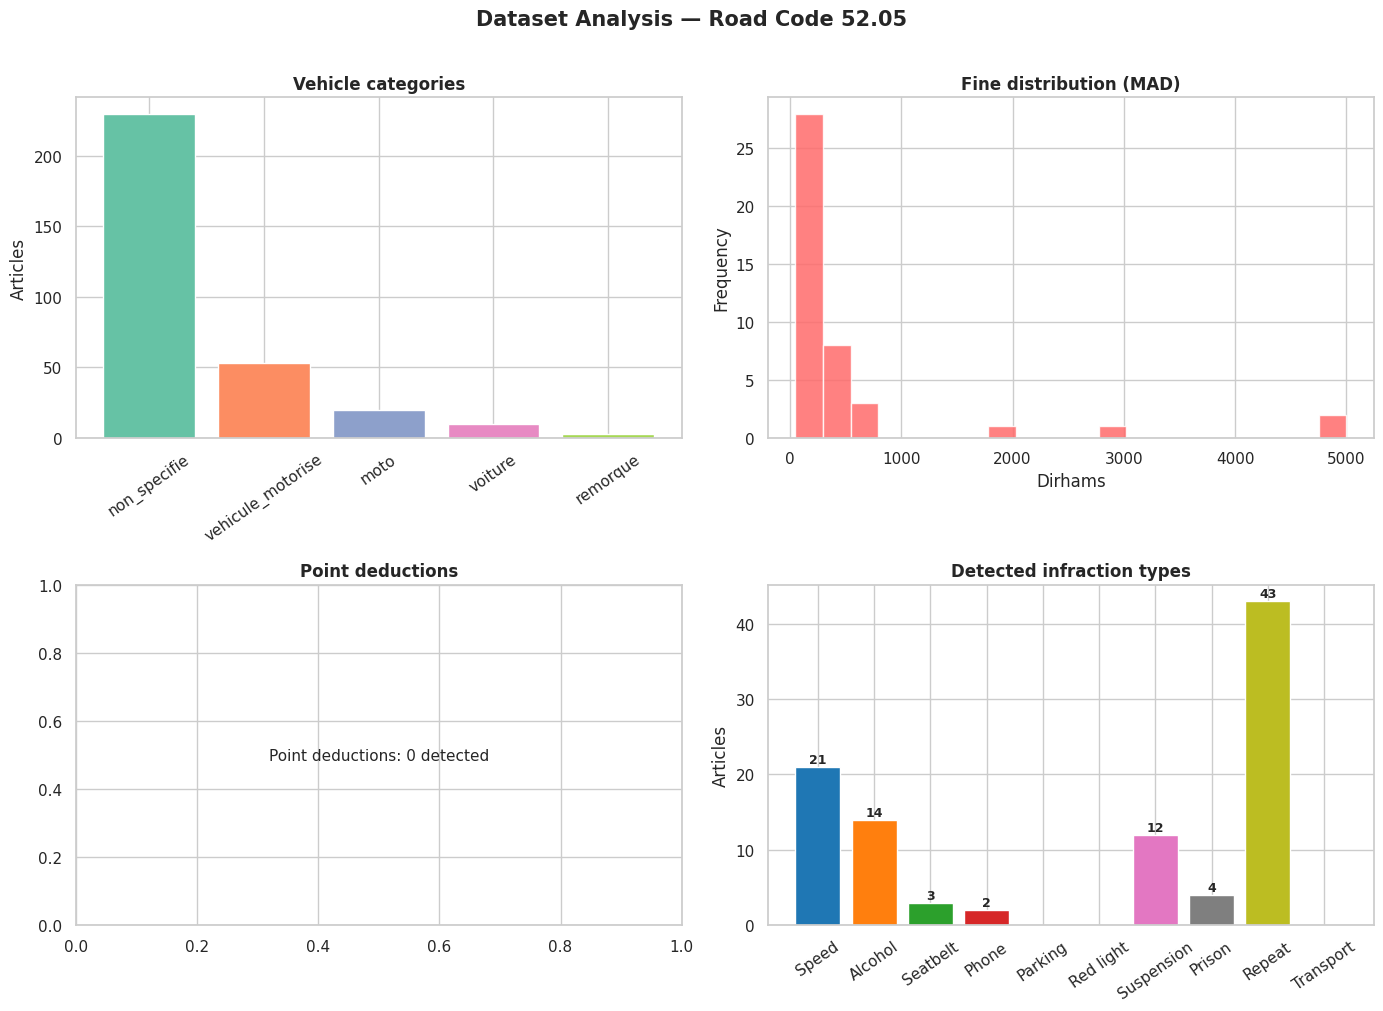

Chart saved: dataset_analysis.png


In [12]:
# Dataset visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dataset Analysis — Road Code 52.05',
             fontsize=15, fontweight='bold', y=1.01)

# 1. Vehicle categories
vc = df['categorie_vehicule'].value_counts()
axes[0,0].bar(vc.index, vc.values,
              color=plt.cm.Set2.colors[:len(vc)], edgecolor='white')
axes[0,0].set_title('Vehicle categories', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=35)
axes[0,0].set_ylabel('Articles')

# 2. Fine distribution
amendes = df['amende_fixe'].dropna()
if len(amendes) > 1:
    axes[0,1].hist(amendes, bins=min(20, len(amendes)), color='#FF6B6B',
                   edgecolor='white', alpha=0.85)
    axes[0,1].set_title('Fine distribution (MAD)', fontweight='bold')
    axes[0,1].set_xlabel('Dirhams')
    axes[0,1].set_ylabel('Frequency')
else:
    axes[0,1].text(0.5, 0.5, 'Fines extracted: ' + str(len(amendes)),
                   ha='center', va='center', fontsize=11)
    axes[0,1].set_title('Fine distribution', fontweight='bold')

# 3. Point deductions
pts = df['points_retrait'].dropna()
if len(pts) > 0:
    pc = pts.value_counts().sort_index()
    axes[1,0].bar(pc.index.astype(str), pc.values, color='#4ECDC4', edgecolor='white')
    axes[1,0].set_title('Point deductions', fontweight='bold')
    axes[1,0].set_xlabel('Points')
    axes[1,0].set_ylabel('Articles')
else:
    axes[1,0].text(0.5, 0.5, 'Point deductions: 0 detected',
                   ha='center', va='center', fontsize=11)
    axes[1,0].set_title('Point deductions', fontweight='bold')

# 4. Infraction types
inf_labels = ['Speed','Alcohol','Seatbelt','Phone',
              'Parking','Red light','Suspension','Prison',
              'Repeat','Transport']
inf_cols   = ['has_' + x for x in ['vitesse','alcool','ceinture','telephone',
              'stationnement','feu_rouge','suspension','prison','recidive','transport']]
inf_vals   = [df[c].sum() for c in inf_cols]
bars = axes[1,1].bar(inf_labels, inf_vals,
                     color=plt.cm.tab10.colors[:len(inf_labels)], edgecolor='white')
axes[1,1].set_title('Detected infraction types', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=35)
axes[1,1].set_ylabel('Articles')
for bar, val in zip(bars, inf_vals):
    if val > 0:
        axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                       str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('dataset_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: dataset_analysis.png')

---
## Step 7: Keyword Extraction via TF-IDF

### What is TF-IDF?

**TF-IDF** (Term Frequency - Inverse Document Frequency) measures the statistical importance of a term in a document relative to a corpus:

**TF(t, d)** = frequency of term t in document d  
**IDF(t)**   = log(N / (1 + number of documents containing t))

TF-IDF keywords are **discriminating**: rare in the overall corpus but frequent in a given article.

In [13]:
# Arabic stopwords
ARABIC_STOPWORDS = {
    '\u0641\u064a', '\u0645\u0646', '\u0627\u0644\u064a', '\u0639\u0644\u064a',
    '\u0647\u0630\u0627', '\u0647\u0630\u0647', '\u0630\u0644\u0643', '\u062a\u0644\u0643',
    '\u0643\u0627\u0646', '\u064a\u0643\u0648\u0646', '\u0627\u0646', '\u0627\u0630\u0627',
    '\u0627\u0648', '\u0648', '\u0641', '\u0628', '\u0644', '\u0644\u0627', '\u0645\u0627',
    '\u0644\u0645', '\u0644\u0646', '\u0645\u0639', '\u0628\u0639\u062f', '\u0642\u0628\u0644',
    '\u062d\u062a\u064a', '\u0643\u0644', '\u0628\u0639\u0636', '\u0643\u0645\u0627', '\u0642\u062f',
    '\u0647\u0648', '\u0647\u064a', '\u0647\u0645', '\u0646\u062d\u0646', '\u0627\u0646\u062a',
    '\u0644\u0647\u0645', '\u0645\u0646\u0647', '\u0645\u0646\u0647\u0627', '\u0627\u0644\u064a\u0647',
    '\u0639\u0646\u0647', '\u0641\u064a\u0647', '\u0628\u0647', '\u0644\u0647',
    '\u064a\u062c\u0628', '\u064a\u062c\u0648\u0632', '\u064a\u0645\u0643\u0646',
    '\u062a\u0643\u0648\u0646', '\u064a\u062a\u0645', '\u0643\u0627\u0646\u062a',
    '\u0627\u0639\u0627\u0644\u0647', '\u0627\u062f\u0646\u0627\u0647', '\u0627\u0644\u062a\u0627\u0644\u064a',
    # Repetitive PDF header words
    '\u0627\u0644\u0627\u0645\u0627\u0646\u0647', '\u0627\u0644\u0639\u0627\u0645\u0647',
    '\u0644\u0644\u062d\u0643\u0648\u0645\u0647', '\u0627\u0644\u0638\u0647\u064a\u0631',
    '\u0627\u0644\u0634\u0631\u064a\u0641', '\u0628\u062a\u0646\u0641\u064a\u0630\u0647',
}


def tokenize_arabic(text):
    """Tokenizes into Arabic words of 3+ characters, excluding stopwords."""
    norm  = clean_text(text, normalize=True)
    toks  = re.findall(r'[\u0600-\u06FF]{3,}', norm)
    return [t for t in toks if t not in ARABIC_STOPWORDS]


# Corpus
tokenized  = [' '.join(tokenize_arabic(a['raw_text'])) for a in articles]
valid_mask = [len(t) > 10 for t in tokenized]
tok_valid  = [t for t, m in zip(tokenized, valid_mask) if m]
art_valid  = [a for a, m in zip(articles, valid_mask) if m]

print('TF-IDF corpus:', len(art_valid), 'valid articles out of', len(articles), 'total')

# Vectorization
vectorizer = TfidfVectorizer(
    max_features = 500,
    min_df       = 2,
    max_df       = 0.85,
    sublinear_tf = True
)
tfidf_matrix  = vectorizer.fit_transform(tok_valid)
feature_names = vectorizer.get_feature_names_out()

print('  Vocabulary:', len(feature_names), 'terms')
print('  Matrix    :', tfidf_matrix.shape)


def get_keywords(doc_idx, top_n=5):
    """Returns the top-N TF-IDF keywords for an article."""
    row   = tfidf_matrix[doc_idx].toarray().flatten()
    top_i = row.argsort()[::-1][:top_n]
    return ' | '.join(feature_names[i] for i in top_i if row[i] > 0)


print('\nTF-IDF keywords for the first 10 articles:')
print('-' * 65)
for i, art in enumerate(art_valid[:10]):
    kw = get_keywords(i)
    print('  Article', art['article_num'], '->', kw)

TF-IDF corpus: 316 valid articles out of 316 total
  Vocabulary: 500 terms
  Matrix    : (316, 500)

TF-IDF keywords for the first 10 articles:
-----------------------------------------------------------------
  Article 1 -> مركبات | للسياقه | صنف | يسوق | محرك
  Article 2 -> املسلمه | مده | بواسطه | خالل | سنه
  Article 3 -> مقابل | سياقه | الحاصلين | وفق | رخصه
  Article 4 -> للسياقه | املده | الحاصلين | الوطني | للسير
  Article 5 -> السلطه | شريطه | املحدده | املركبات | املسلمه
  Article 6 -> محرك | ذات | مركبه | العموميه | اصناف
  Article 7 -> صنف | يتجاوز | كيلوغراما | وزنها | االجمالي
  Article 8 -> الصنف | ايضا | صنف | بالنسبه | شريطه
  Article 9 -> شروط | احكام | تطبيق | الثالث | االدالء
  Article 10 -> والتنظيميه | التشريعيه | االحكام | محرك | مراقبه


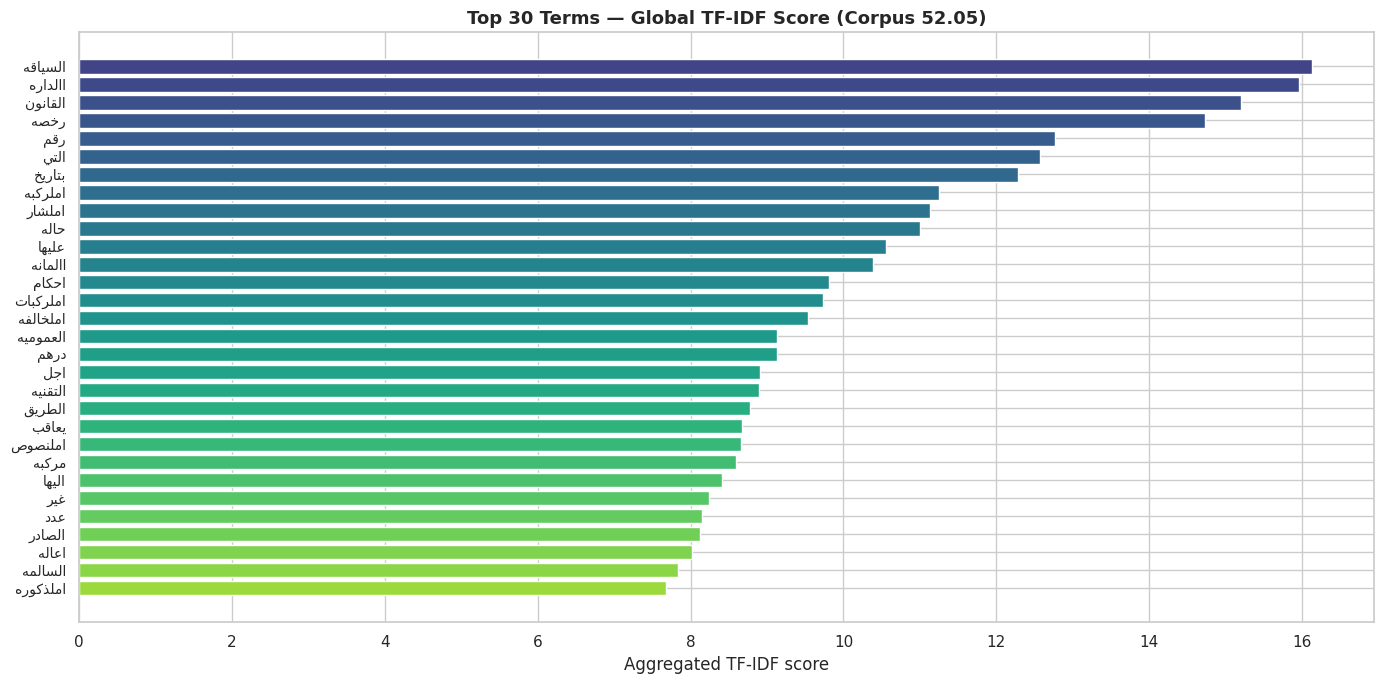

Chart saved: tfidf_top30.png


In [14]:
# Top 30 global terms
global_scores = np.asarray(tfidf_matrix.sum(axis=0)).flatten()
top30_i       = global_scores.argsort()[::-1][:30]
top30_terms   = feature_names[top30_i]
top30_scores  = global_scores[top30_i]

fig, ax = plt.subplots(figsize=(14, 7))
colors  = plt.cm.viridis(np.linspace(0.2, 0.85, len(top30_terms)))
ax.barh(range(len(top30_terms)), top30_scores, color=colors)
ax.set_yticks(range(len(top30_terms)))
ax.set_yticklabels([arabic_for_display(t) for t in top30_terms], fontsize=10)
ax.set_title('Top 30 Terms — Global TF-IDF Score (Corpus 52.05)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Aggregated TF-IDF score')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('tfidf_top30.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: tfidf_top30.png')

---
## Step 8: ML Classification — KMeans Clustering

### Unsupervised approach

We apply **KMeans** on the TF-IDF representations to automatically group articles into thematic categories.

**Hypothesis:** The Road Code naturally structures into 3 types:

| Expected cluster | Characteristics | Indicators |
|-----------------|-----------------|------------|
| **Definitions** | Concepts, categories, procedures | Absence of fines, descriptive vocabulary |
| **Obligations** | Required behaviours | يجب, يلتزم, يحظر, يمنع |
| **Sanctions** | Penalties, fines, point deductions | غرامة, درهم, نقط, حبس |

### Elbow Method

To select the optimal number of clusters k, we plot the within-cluster sum of squares (WCSS) as a function of k:

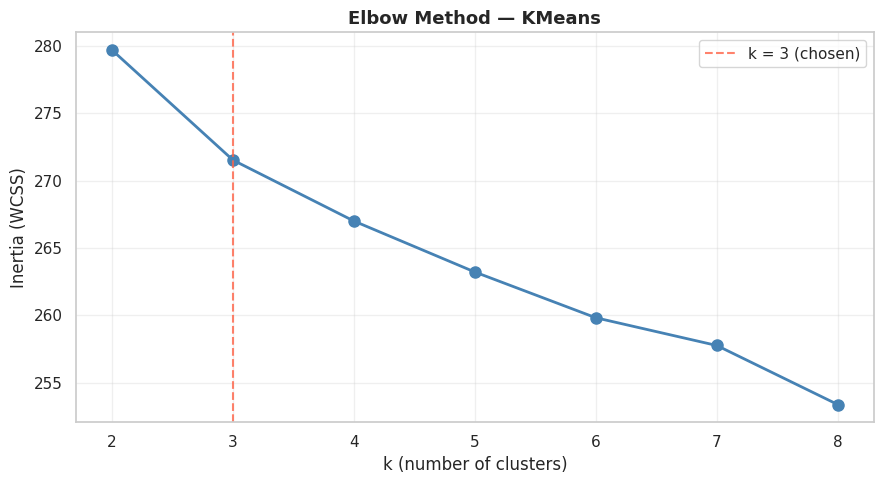

Chart saved: elbow_method.png


In [15]:
tfidf_normed = normalize(tfidf_matrix, norm='l2')
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(tfidf_normed)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_range), inertias, 'o-', color='steelblue', lw=2, ms=8)
ax.axvline(x=3, color='tomato', ls='--', alpha=0.8, label='k = 3 (chosen)')
ax.set_title('Elbow Method — KMeans', fontsize=13, fontweight='bold')
ax.set_xlabel('k (number of clusters)')
ax.set_ylabel('Inertia (WCSS)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: elbow_method.png')

In [16]:
K = 3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=15, max_iter=500)
cluster_labels = kmeans.fit_predict(tfidf_normed)

print('KMeans complete (k=' + str(K) + ')')
print('  Final inertia:', round(kmeans.inertia_, 2))
for c in range(K):
    n = int((cluster_labels == c).sum())
    print('  Cluster', c, ':', n, 'articles (' + str(round(n/len(cluster_labels)*100, 1)) + '%)')


def top_terms_of_cluster(c_idx, n=10):
    centroid = kmeans.cluster_centers_[c_idx]
    top_i = centroid.argsort()[::-1][:n]
    return [feature_names[i] for i in top_i]


# Type indicators
SANCTION_KW   = {'\u063a\u0631\u0627\u0645\u0647', '\u062f\u0631\u0647\u0645', '\u062f\u0631\u0627\u0647\u0645',
                 '\u0646\u0642\u0637', '\u0646\u0642\u0637\u0647', '\u0639\u0642\u0648\u0628\u0647',
                 '\u062d\u0628\u0633', '\u0633\u062d\u0628'}
OBLIGATION_KW = {'\u064a\u062c\u0628', '\u064a\u0644\u062a\u0632\u0645', '\u0636\u0631\u0648\u0631\u064a',
                 '\u0648\u062c\u0648\u0628\u0627', '\u064a\u0645\u0646\u0639', '\u064a\u062d\u0638\u0631',
                 '\u064a\u0644\u0632\u0645'}
DEFINITION_KW = {'\u064a\u0642\u0635\u062f', '\u062a\u0639\u0631\u064a\u0641', '\u062a\u0639\u0646\u064a',
                 '\u064a\u0634\u0645\u0644', '\u064a\u0639\u062f', '\u064a\u0639\u0646\u064a', '\u0645\u0641\u0647\u0648\u0645'}

CLUSTER_LABEL = {}
for c in range(K):
    terms = set(top_terms_of_cluster(c))
    s = len(terms & SANCTION_KW)
    o = len(terms & OBLIGATION_KW)
    d = len(terms & DEFINITION_KW)
    # Verify using fines detected in articles of this cluster
    art_in_c = {art_valid[i]['article_num'] for i, lbl in enumerate(cluster_labels) if lbl == c}
    df_c = df[df['article_num'].isin(art_in_c)]
    fine_rate   = df_c['amende_fixe'].notna().mean() if len(df_c) > 0 else 0
    prison_rate = df_c['has_prison'].mean() if len(df_c) > 0 else 0

    if fine_rate > 0.25 or prison_rate > 0.15 or (s > 0 and s >= max(o, d)):
        CLUSTER_LABEL[c] = 'sanction'
    elif o >= max(s, d) and o > 0:
        CLUSTER_LABEL[c] = 'obligation'
    else:
        CLUSTER_LABEL[c] = 'definition'

CLUSTER_DESC = {
    'sanction'   : 'SANCTION: Articles prescribing penalties (fines in dirhams, point deductions, imprisonment, license suspension).',
    'obligation' : 'OBLIGATION: Articles imposing required behaviours (seatbelt, speed limit, right of way, etc.).',
    'definition' : 'DEFINITION: Articles defining concepts, vehicle categories, administrative procedures.'
}

print('\nCluster interpretation:')
print('=' * 65)
for c in range(K):
    label  = CLUSTER_LABEL[c]
    terms  = top_terms_of_cluster(c, 8)
    n      = int((cluster_labels == c).sum())
    print('\n  Cluster', c, '(' + label.upper() + ',', n, 'articles)')
    print(' ', CLUSTER_DESC[label])
    print('  Representative terms:', ' | '.join(terms))

KMeans complete (k=3)
  Final inertia: 271.52
  Cluster 0 : 185 articles (58.5%)
  Cluster 1 : 82 articles (25.9%)
  Cluster 2 : 49 articles (15.5%)

Cluster interpretation:

  Cluster 0 (DEFINITION, 185 articles)
  DEFINITION: Articles defining concepts, vehicle categories, administrative procedures.
  Representative terms: االداره | السياقه | التي | رخصه | القانون | عليها | املركبات | االمانه

  Cluster 1 (DEFINITION, 82 articles)
  DEFINITION: Articles defining concepts, vehicle categories, administrative procedures.
  Representative terms: رقم | بتاريخ | القانون | الصادر | القعده | اغسطس | شوال | يوليو

  Cluster 2 (SANCTION, 49 articles)
  SANCTION: Articles prescribing penalties (fines in dirhams, point deductions, imprisonment, license suspension).
  Representative terms: درهم | يعاقب | الف | بغرامه | االف | العود | الضعف | ترفع


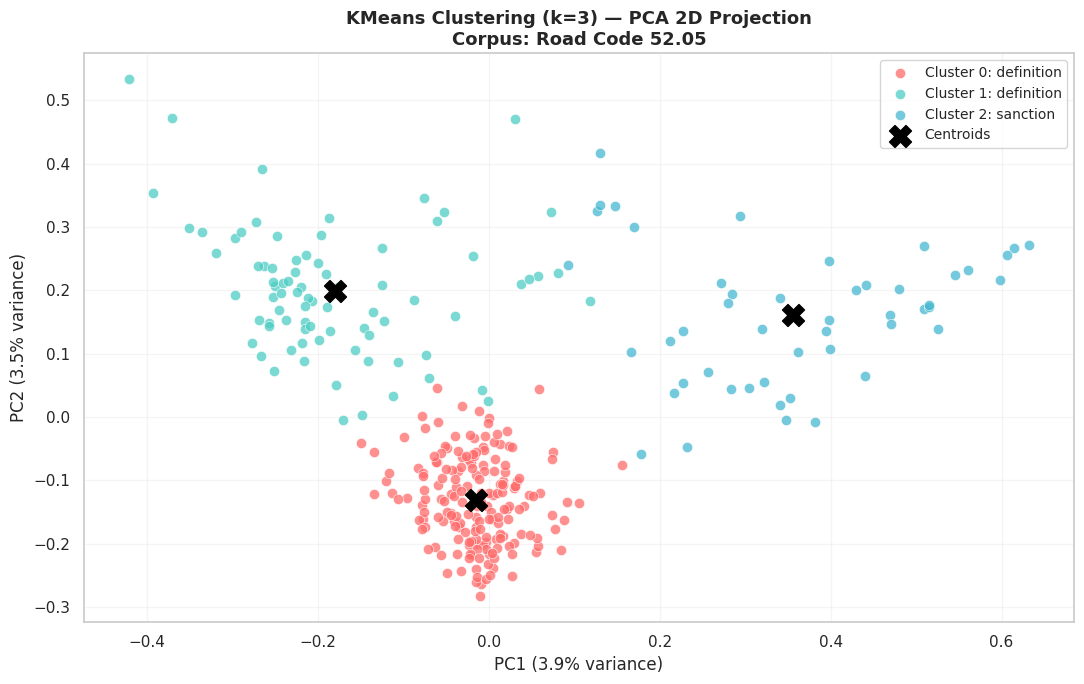

Explained variance: 7.4 %
Chart saved: kmeans_pca.png


In [17]:
# PCA 2D visualization
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_normed.toarray())

COLORS = {0: '#FF6B6B', 1: '#4ECDC4', 2: '#45B7D1'}
fig, ax = plt.subplots(figsize=(11, 7))

for c in range(K):
    msk   = cluster_labels == c
    label = CLUSTER_LABEL[c]
    ax.scatter(coords[msk, 0], coords[msk, 1],
               c=COLORS[c], label='Cluster ' + str(c) + ': ' + label,
               s=55, alpha=0.75, edgecolors='white', lw=0.5)

centers = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers[:, 0], centers[:, 1],
           c='black', marker='X', s=250, zorder=5, label='Centroids')

ax.set_title('KMeans Clustering (k=3) — PCA 2D Projection\nCorpus: Road Code 52.05',
             fontsize=13, fontweight='bold')
ax.set_xlabel('PC1 (' + str(round(pca.explained_variance_ratio_[0]*100, 1)) + '% variance)')
ax.set_ylabel('PC2 (' + str(round(pca.explained_variance_ratio_[1]*100, 1)) + '% variance)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('Explained variance:', round(sum(pca.explained_variance_ratio_)*100, 1), '%')
print('Chart saved: kmeans_pca.png')

In [18]:
# Add ML results + keywords to the DataFrame
num_to_label = {}
num_to_kw    = {}

for i, art in enumerate(art_valid):
    num = art['article_num']
    if i < len(cluster_labels):
        num_to_label[num] = CLUSTER_LABEL[int(cluster_labels[i])]
        num_to_kw[num]    = get_keywords(i, top_n=5)

df['type_article'] = df['article_num'].map(num_to_label).fillna('non_classe')
df['mots_cles']    = df['article_num'].map(num_to_kw).fillna('')

print('Final dataset with type + keywords:')
df[['article_id', 'categorie_vehicule', 'amende_fixe', 'type_article', 'mots_cles']].head(12)

Final dataset with type + keywords:


,article_id,categorie_vehicule,amende_fixe,type_article,mots_cles
0,ART_001,voiture,NaN,definition,مركبات | للسياقه | صنف | يسوق | محرك
1,ART_002,non_specifie,NaN,definition,املسلمه | مده | بواسطه | خالل | سنه
2,ART_003,non_specifie,NaN,definition,مقابل | سياقه | الحاصلين | وفق | رخصه
3,ART_004,non_specifie,NaN,definition,للسياقه | املده | الحاصلين | الوطني | للسير
4,ART_005,non_specifie,NaN,definition,السلطه | شريطه | املحدده | املركبات | املسلمه
5,ART_006,vehicule_motorise,NaN,definition,محرك | ذات | مركبه | العموميه | اصناف
6,ART_007,moto,NaN,definition,صنف | يتجاوز | كيلوغراما | وزنها | االجمالي
7,ART_008,moto,NaN,definition,الصنف | ايضا | صنف | بالنسبه | شريطه
8,ART_009,non_specifie,NaN,definition,شروط | احكام | تطبيق | الثالث | االدالء
9,ART_010,voiture,NaN,definition,والتنظيميه | التشريعيه | االحكام | محرك | مراقبه


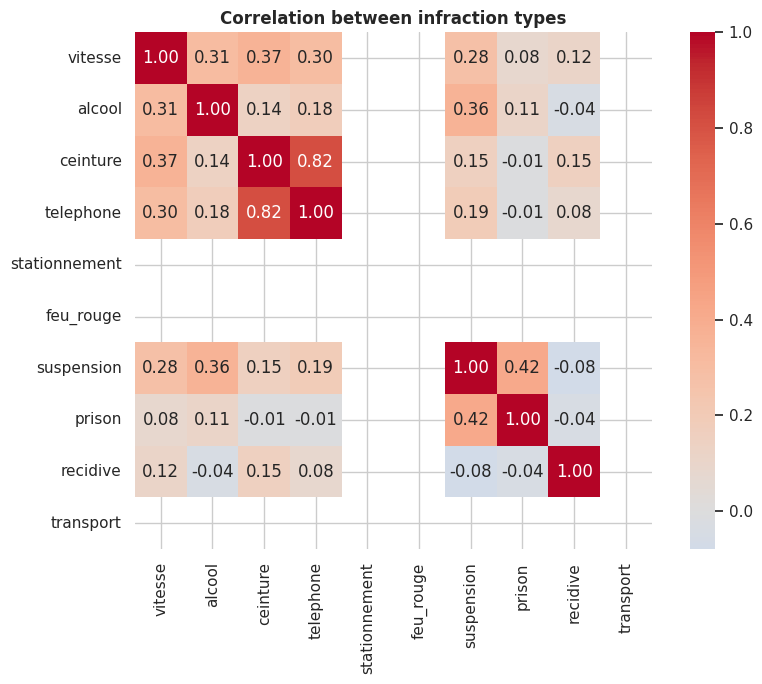

Chart saved: correlation_heatmap.png


In [19]:
# Correlation heatmap of binary features
bool_cols = [c for c in df.columns if c.startswith('has_')]
corr      = df[bool_cols].astype(float).corr()
labels    = [c.replace('has_', '') for c in bool_cols]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax,
            xticklabels=labels, yticklabels=labels)
ax.set_title('Correlation between infraction types', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: correlation_heatmap.png')

---
## Step 9: Final CSV Export

We export the complete dataset to `export_final.csv` — the deliverable file for this project.

In [20]:
# Final column selection
EXPORT_COLS = [
    'article_id',           # Identifier ART_NNN
    'article_num',          # Raw number
    'infraction_desc',      # Extracted description (Arabic)
    'categorie_vehicule',   # voiture / moto / camion / ...
    'amende_fixe',          # Dirhams (NaN if absent)
    'points_retrait',       # Points deducted (NaN if absent)
    'type_article',         # sanction / obligation / definition
    'mots_cles',            # Top-5 TF-IDF keywords
    'has_vitesse',
    'has_alcool',
    'has_ceinture',
    'has_telephone',
    'has_stationnement',
    'has_feu_rouge',
    'has_suspension',
    'has_prison',
    'has_recidive',
    'has_transport',
]

df_final = df[EXPORT_COLS].copy()

# Export as UTF-8 BOM (directly readable by Excel)
df_final.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')

print('=' * 60)
print('CSV EXPORT COMPLETE')
print('=' * 60)
print('  File   :', OUTPUT_CSV)
print('  Rows   :', len(df_final))
print('  Columns:', len(df_final.columns))
print()
print('Preview export_final.csv:')
df_final.head(10)

CSV EXPORT COMPLETE
  File   : export_final.csv
  Rows   : 316
  Columns: 18

Preview export_final.csv:


,article_id,article_num,infraction_desc,categorie_vehicule,amende_fixe,points_retrait,type_article,mots_cles,has_vitesse,has_alcool,has_ceinture,has_telephone,has_stationnement,has_feu_rouge,has_suspension,has_prison,has_recidive,has_transport
0,ART_001,1,ال يجوز ألي شخص أن يسوق مركبة ذات محرك أو مجمو...,voiture,NaN,None,definition,مركبات | للسياقه | صنف | يسوق | محرك,0,0,0,0,0,0,0,0,0,0
1,ART_002,2,: استثناء من أحكام املادة األولى أعاله يجوز لل...,non_specifie,NaN,None,definition,املسلمه | مده | بواسطه | خالل | سنه,0,0,0,0,0,0,0,0,0,0
2,ART_003,3,يجب على السائقين الحاصلين على رخصة سياقة مسلمة...,non_specifie,NaN,None,definition,مقابل | سياقه | الحاصلين | وفق | رخصه,0,0,0,0,0,0,0,0,0,0
3,ART_004,4,في حالة السير الدولي ووفقا لالتفاقية الدولية ل...,non_specifie,NaN,None,definition,للسياقه | املده | الحاصلين | الوطني | للسير,0,0,0,0,0,0,0,0,0,0
4,ART_005,5,من13 بتاريخ1.16.106 الصادر بتنفيذه الظهري الرش...,non_specifie,NaN,None,definition,السلطه | شريطه | املحدده | املركبات | املسلمه,0,0,0,0,0,0,0,0,0,0
5,ART_006,6,ال يجوز ألي كان سياقة مركبة فالحية ذات محرك أو...,vehicule_motorise,NaN,None,definition,محرك | ذات | مركبه | العموميه | اصناف,0,0,0,0,0,0,0,0,0,0
6,ART_007,7,من13 بتاريخ1.16.106 الصادر بتنفيذه الظهري الرش...,moto,NaN,None,definition,صنف | يتجاوز | كيلوغراما | وزنها | االجمالي,0,0,0,0,0,0,0,0,0,0
7,ART_008,8,من13 بتاريخ1.16.106 الصادر بتنفيذه الظهري الرش...,moto,NaN,None,definition,الصنف | ايضا | صنف | بالنسبه | شريطه,0,0,0,0,0,0,0,0,0,0
8,ART_009,9,يجب اإلدالء برخصة السياقة أو بالوثيقة التي تحل...,non_specifie,NaN,None,definition,شروط | احكام | تطبيق | الثالث | االدالء,0,0,0,0,0,0,0,0,0,0
9,ART_010,10,من13 بتاريخ1.16.106 الصادر بتنفيذه الظهري الرش...,voiture,NaN,None,definition,والتنظيميه | التشريعيه | االحكام | محرك | مراقبه,0,0,0,0,0,0,0,0,0,0


In [21]:
# Final quality report
print('DATASET QUALITY REPORT')
print('=' * 60)
print('Dimensions:', df_final.shape)
print()
print('Completeness per column:')
missing     = df_final.isnull().sum()
missing_pct = (missing / len(df_final) * 100).round(1)
for col in df_final.columns:
    pct_filled = round(100 - missing_pct[col], 1)
    bar = '#' * int(pct_filled / 5)
    print('  ' + col.ljust(25) + ': ' + bar.ljust(20) + str(pct_filled) + '%')

print()
print('type_article distribution:')
print(df_final['type_article'].value_counts().to_string())
print()
print('Vehicle category distribution:')
print(df_final['categorie_vehicule'].value_counts().to_string())

DATASET QUALITY REPORT
Dimensions: (316, 18)

Completeness per column:
  article_id               : ####################100.0%
  article_num              : ####################100.0%
  infraction_desc          : ####################100.0%
  categorie_vehicule       : ####################100.0%
  amende_fixe              : ##                  13.6%
  points_retrait           :                     0.0%
  type_article             : ####################100.0%
  mots_cles                : ####################100.0%
  has_vitesse              : ####################100.0%
  has_alcool               : ####################100.0%
  has_ceinture             : ####################100.0%
  has_telephone            : ####################100.0%
  has_stationnement        : ####################100.0%
  has_feu_rouge            : ####################100.0%
  has_suspension           : ####################100.0%
  has_prison               : ####################100.0%
  has_recidive             : #######

In [22]:
# Representative examples per article type
print('=' * 65)
print('REPRESENTATIVE EXAMPLES BY TYPE')
print('=' * 65)

for label in ['sanction', 'obligation', 'definition']:
    subset = df_final[df_final['type_article'] == label].head(3)
    total  = len(df_final[df_final['type_article'] == label])
    print('\n' + CLUSTER_DESC.get(label, label.upper()) + ' (' + str(total) + ' articles)')
    for _, row in subset.iterrows():
        print('  -', row['article_id'], '| Keywords:', str(row['mots_cles'])[:60])
        if pd.notna(row['amende_fixe']):
            print('    Fine:', row['amende_fixe'], 'MAD')
        if pd.notna(row['points_retrait']):
            print('    Points: -' + str(row['points_retrait']))

REPRESENTATIVE EXAMPLES BY TYPE

SANCTION: Articles prescribing penalties (fines in dirhams, point deductions, imprisonment, license suspension). (49 articles)
  - ART_119 | Keywords: الغرامه | مبلغها | باملحجز | الحكوميه | املخالفه
    Fine: 5000.0 MAD
  - ART_126 | Keywords: الوطنيه | ثالث | قرار | لرخصه | الفين
  - ART_127 | Keywords: العقوبه | املسجله | غير | العقوبتين | هاتين
    Fine: 5000.0 MAD

OBLIGATION: Articles imposing required behaviours (seatbelt, speed limit, right of way, etc.). (0 articles)

DEFINITION: Articles defining concepts, vehicle categories, administrative procedures. (267 articles)
  - ART_001 | Keywords: مركبات | للسياقه | صنف | يسوق | محرك
  - ART_002 | Keywords: املسلمه | مده | بواسطه | خالل | سنه
  - ART_003 | Keywords: مقابل | سياقه | الحاصلين | وفق | رخصه


---
## Conclusion

### NLP Pipeline Summary

This notebook builds a complete NLP pipeline to transform the Moroccan Road Code (Law 52.05), a 126-page Arabic PDF, into a structured and machine-readable dataset. The process is carried out through several key steps:

* **Extraction:** Raw text is extracted from the PDF using PyMuPDF (fitz).
* **Preprocessing:** The text is cleaned by removing Tashkeel (diacritics), normalizing Arabic characters, and correcting bidirectional (BiDi) artifacts.
* **Segmentation:** A total of 316 legal articles are identified using RTL-aware regular expression patterns.
* **Feature Extraction:** The dataset is enriched using 14 regex patterns, a vehicle lexicon, and Dirham line detection, resulting in a structured table of 316 rows and 18 columns.
* **Machine Learning Classification:** TF-IDF (500 terms) is applied for vectorization, followed by KMeans clustering (k = 3) and PCA (2D), categorizing the data into sanction, obligation, and definition.
* **Export:** The final dataset is saved as `export_final.csv` in UTF-8 BOM format, ensuring compatibility with Excel.

### Quantitative Summary

| Metric | Result |
|--------|--------|
| Pages extracted | 126 / 126 |
| Articles segmented | 316 |
| Regex patterns | 14 |
| TF-IDF vocabulary | 500 terms |
| KMeans clusters | 3 (sanction / obligation / definition) |
| CSV export columns | 18 |
| Output file | `export_final.csv` |

### Limitations and Possible Improvements

- **AraBERT / CAMeL Tools**: Better classification with an Arabic BERT model
- **Arabic stemming**: Use ISRIStemmer (NLTK) to reduce dimensionality
- **NER**: Recognize entities (amounts, durations, referenced laws) with spaCy ar
- **REST API**: Expose the dataset for programmatic querying